# Week 12 Demo: Estimating Causal Effects Under Interference
## Exposure Mapping for Spillover Effects in Social Network Experiments

### By Farhan Shaikh and Elena Murray

This demo is based on the paper 'Estimating Average Causal Effects Under General Interference, with Application to a Social Network Experiment' by Aronow and Samii (2017). 

ADD HERE: Brief summary of the main points of the paper and key theoretical concepts. 

### Section 1: Social Network Data

ADD HERE: Introduce the dataset. 

To demonstrate this, we will be working with the same data used by Aronow and Samii in Section 10 of the paper: Analysis of a social network experiment. 

This analysis uses data from a real experiment conducted for a previous study by Paluck, Shepard and Aronow (2016). It comes from a field experiment with 56 middle schools in the US, as part of a study on reducing peer conflict and bullying. 

Information about the data and experiment here.

In [2]:
#Load the data
#Inspect the data and structure

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(
    r"C:\Users\FARHAN SHAIKH\Desktop\Farhan\Personal\Hertie School\Programme Documents\Courses\Sem 3\Causal Machine Learning\Demo Repos\demonstration-farhan-elena\Data\da37070_0001.csv",
    engine="python",
    on_bad_lines="skip"
)


# All ICPSR missing codes we want to set to NaN
missing_codes = [-55, -66, -77, -88, -95, -96, -97, -98, -99]

df = df.replace(missing_codes, np.nan)

# Keep only the columns needed for network + treatment + outcomes
network_cols = [col for col in df.columns if col.startswith(("BF", "ST"))]
treat_cols = ["SCHTREAT", "TREAT"]
id_cols = ["SCHID", "UID"]      # school and unique student ID

# Combine into an analysis dataset
df_net = df[id_cols + treat_cols + network_cols]
df_net.head()

,SCHID,UID,SCHTREAT,TREAT,STRB,ST1,ST2,ST3,ST4,ST5,...,ST3W2,ST4W2,ST5W2,ST6W2,ST7W2,ST8W2,ST9W2,ST10W2,BF1W2,BF2W2
0,1,100001,(1) Treatment school (Roots meetings 2012-2013),(0) Not treatment or control,0.0,12.0,999.0,140.0,13.0,28.0,...,15.0,23.0,12.0,59.0,178.0,209.0,45.0,272.0,178.0,268.0
1,1,100002,(1) Treatment school (Roots meetings 2012-2013),(2) Control,4.0,21.0,31.0,7.0,20.0,13.0,...,15.0,20.0,3.0,21.0,178.0,180.0,181.0,209.0,4.0,5.0
2,1,100003,(1) Treatment school (Roots meetings 2012-2013),(0) Not treatment or control,0.0,999.0,1.0,45.0,20.0,72.0,...,45.0,2.0,269.0,31.0,18.0,70.0,276.0,72.0,203.0,2.0
3,1,100004,(1) Treatment school (Roots meetings 2012-2013),(0) Not treatment or control,0.0,19.0,24.0,32.0,22.0,8.0,...,271.0,67.0,45.0,13.0,20.0,NaN,NaN,NaN,271.0,22.0
4,1,100005,(1) Treatment school (Roots meetings 2012-2013),(0) Not treatment or control,0.0,258.0,10.0,4.0,32.0,45.0,...,32.0,75.0,93.0,102.0,142.0,2.0,4.0,1.0,21.0,NaN


In [3]:
#Build the Social Network 

#Using graph: https://networkx.org/documentation/stable/reference/classes/graph.html

# Extract friend nominations (can be BF1, BF2, BF3, …)
friend_cols = [c for c in df_net.columns if c.startswith("BF")]

edges = []

for _, row in df_net.iterrows():
    uid = row["UID"]
    for col in friend_cols:
        friend = row[col]
        if pd.notna(friend):               # valid nomination
            edges.append((uid, int(friend)))

edges_df = pd.DataFrame(edges, columns=["source", "target"])
print("Sample of extracted edges:")
print(edges_df.head())

Sample of extracted edges:
   source  target
0  100001     140
1  100001      12
2  100001     178
3  100001     268
4  100002      21


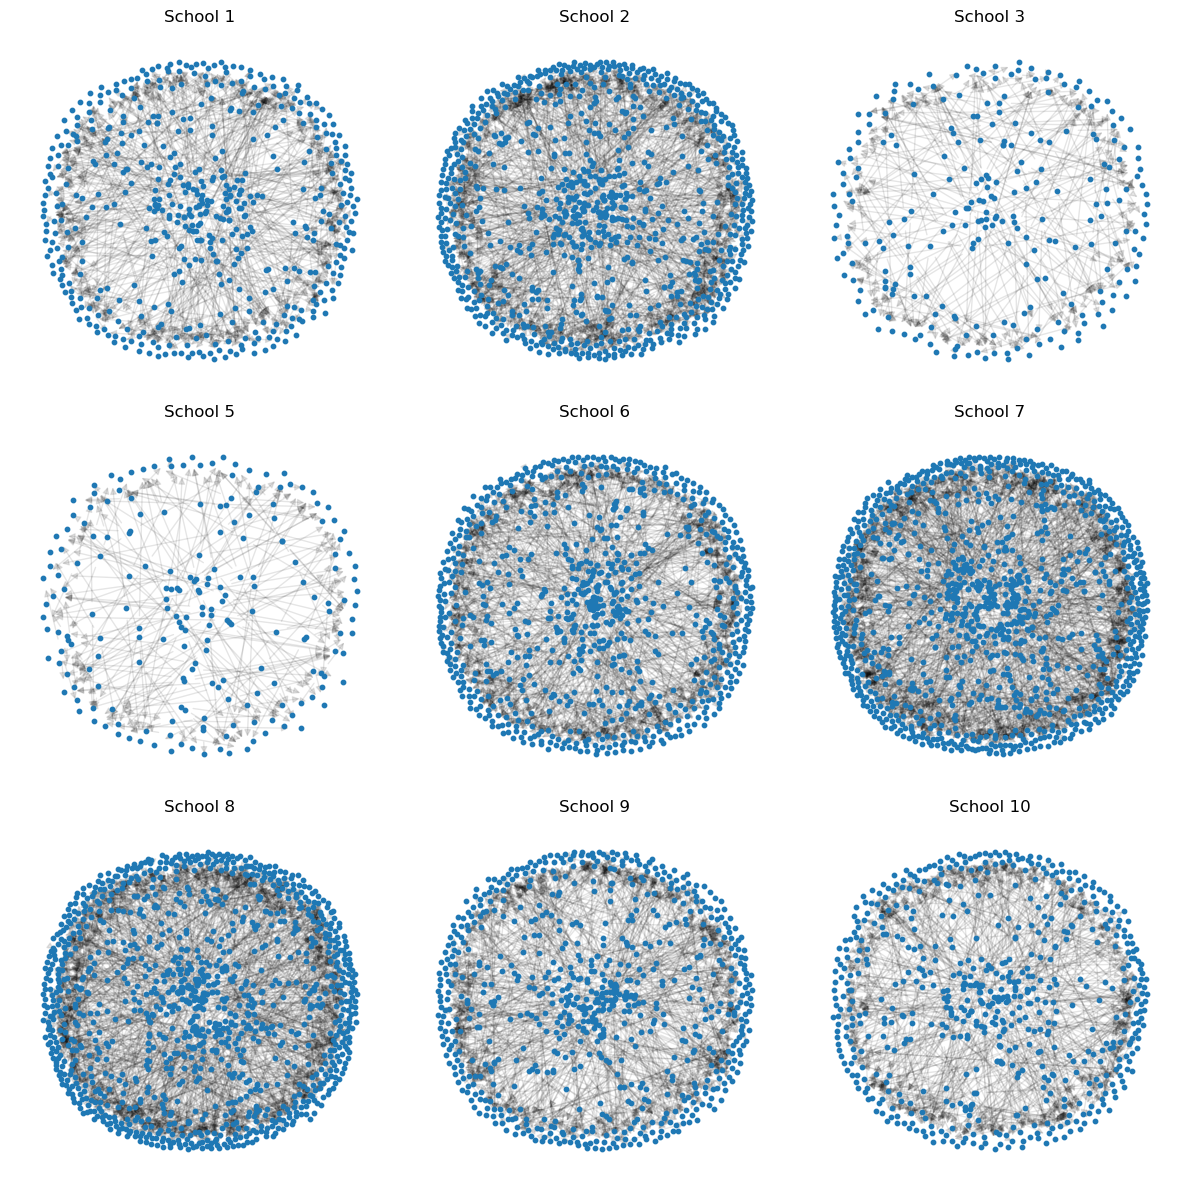

In [6]:
#Display basic network stats
import networkx as nx
import matplotlib.pyplot as plt

unique_schools = df["SCHID"].unique()[:9]  # first 9 schools

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, sid in zip(axes.flatten(), unique_schools):
    sub_nodes = df[df["SCHID"] == sid]["UID"]
    sub_edges = edges_df[edges_df["source"].isin(sub_nodes)]
    Gs = nx.from_pandas_edgelist(sub_edges, "source", "target", create_using=nx.DiGraph())
    
    pos = nx.spring_layout(Gs, seed=1)
    nx.draw_networkx_nodes(Gs, pos, node_size=10, ax=ax)
    nx.draw_networkx_edges(Gs, pos, alpha=0.1, ax=ax)
    ax.set_title(f"School {sid}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Section 2: Exposure Mapping

Use the 5-category mapping from Section 10 (Table 2):
	•	d000: No treatment, program not in school
	•	d001: School-level exposure only
	•	d011: Indirect (≥1 treated neighbor)
	•	d101: Direct treatment only
	•	d111: Direct + Indirect exposure

In [7]:
#Simple exposure mapping

def compute_exposure_basic(G,Z):
    """"
    Inputs:
    G: networkx graph (directed or undirected)
    Z: dict {node: treatment} OR pandas Series

    Output:
        exposure : dict {node: exposure_category}
    """

    exposure={}
    A=nx.to_numpy_array(G, nodelist=list(G.nodes()))
    nodes=list(G.nodes())

    #Convert Z to aligned array
    Z_arr=np.array([Z[n] for n in nodes])

    #Count treated neighbours: A * Z vector
    neigh_treated=A.dot(Z_arr)

    for idx, node in enumerate(nodes):
        own=Z_arr[idx]
        neigh=neigh_treated[idx]

        #Exposure conditions
        if own==0 and neigh==0:
            exp="d1"
        elif own==0 and neigh>0:
            exp="d2"
        elif own==1 and neigh==0:
            exp="d3"
        else:
            exp="d4"
        
        exposure[node]=exp
    
    return exposure



In [ ]:
#Visualise exposure mapping flows

### Section 3: Approximate Exposure Probabilities πᵢ(dₖ)

In [ ]:
#Calculate here

### Section 4: HT estimators 

In [ ]:
#Calculate here

### Section 5: Playground

Where other students can modify features to see different results.

In [ ]:
#Possible changes: modify exposure mapping (eg. number of treated nieghbours >2, fractional exposure >q treated neighbours, include 2 hop neighbours)

#Visualise results

ADD: Brief text for a conclusion with main takeaways. 